In [175]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# X = np.load("X_filtered.npy")
# y = np.load("y_filtered.npy")

# print(X.shape, y.shape)

(81, 64, 64, 18) (81, 64, 64)


In [327]:
X_train=np.load("X_train0.npy")
X_test=np.load("X_test0.npy")
y_train=np.load("y_train0.npy")
y_test=np.load("y_test0.npy")

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60, 64, 64, 18) (60, 64, 64, 1)
(61, 64, 64, 18) (61, 64, 64, 1)


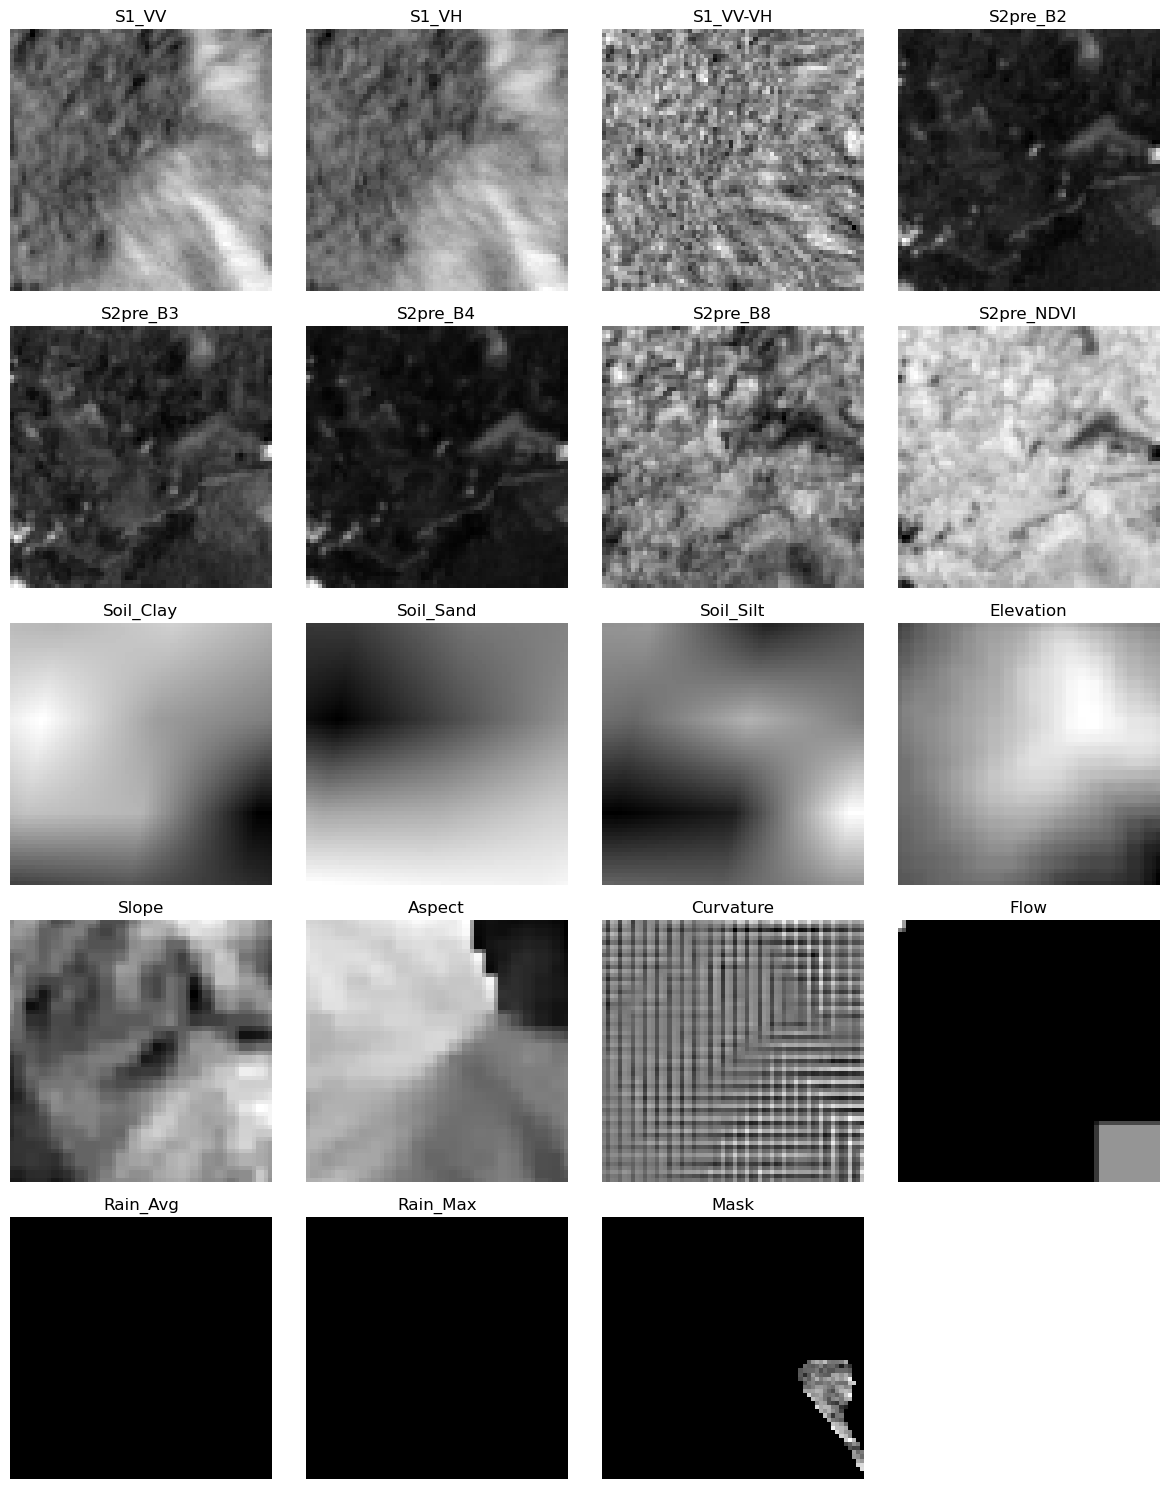

In [271]:
band_names_full = [
    "S1_VV", "S1_VH", "S1_VV-VH",

    "S2pre_B2", "S2pre_B3", "S2pre_B4", "S2pre_B8", "S2pre_NDVI",

    "Soil_Clay", "Soil_Sand", "Soil_Silt",

    "Elevation", "Slope", "Aspect", "Curvature", "Flow",

    "Rain_Avg", "Rain_Max"
]

keep = [i for i in range(len(band_names_full))]
band_names = [band_names_full[i] for i in keep]

import matplotlib.pyplot as plt

i = 0

X = X_train
y = y_train

num_bands = X.shape[3]
cols = 4
rows = (num_bands + 1 + cols - 1) // cols

plt.figure(figsize=(12, 3*rows))

for b in range(num_bands):
    plt.subplot(rows, cols, b + 1)
    plt.imshow(X[i][:,:,b], cmap='gray')
    plt.title(band_names[b])   # ✅ actual name
    plt.axis('off')

# Mask
plt.subplot(rows, cols, num_bands + 1)
plt.imshow(y[i][:,:,0], cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

In [142]:
# X = X.astype(np.float32)

# for b in range(X.shape[3]):
#     X[:,:,:,b] = (X[:,:,:,b] - X[:,:,:,b].mean()) / (X[:,:,:,b].std() + 1e-6)

In [143]:
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

In [328]:
X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float()
y_train = torch.tensor(y_train).permute(0, 3, 1, 2).float()

X_test = torch.tensor(X_test).permute(0, 3, 1, 2).float()
y_test = torch.tensor(y_test).permute(0, 3, 1, 2).float()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [277]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=8,
    shuffle=True
)

In [311]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.d1 = DoubleConv(in_channels, 64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128, 256)
        self.p3 = nn.MaxPool2d(2)

        self.bn = DoubleConv(256, 512)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c3 = DoubleConv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)
        # self.skip_proj = nn.Conv2d(5, 1, kernel_size=1)
        self.fuse = nn.Conv2d(in_channels=6, out_channels=1, kernel_size=1)

    def forward(self, x):
        x_in = x   # save input

        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2))

        bn = self.bn(self.p3(d3))

        u3 = self.u3(bn)
        u3 = self.c3(torch.cat([u3, d3], dim=1))

        u2 = self.u2(u3)
        u2 = self.c2(torch.cat([u2, d2], dim=1))

        u1 = self.u1(u2)
        u1 = self.c1(torch.cat([u1, d1], dim=1))

        out = self.out(u1)                          # (B,1,H,W)
        s2_pre = x_in[:, 3:8, :, :]                 # (B,5,H,W)

        fused = torch.cat([out, s2_pre], dim=1)     # (B,6,H,W)

        out = self.fuse(fused)                      # (B,1,H,W)
        out = torch.sigmoid(out)
        return out

In [229]:
# def forward(self, x):
#         d1 = self.d1(x)
#         d2 = self.d2(self.p1(d1))
#         d3 = self.d3(self.p2(d2))

#         bn = self.bn(self.p3(d3))

#         u3 = self.u3(bn)
#         u3 = self.c3(torch.cat([u3, d3], dim=1))

#         u2 = self.u2(u3)
#         u2 = self.c2(torch.cat([u2, d2], dim=1))

#         u1 = self.u1(u2)
#         u1 = self.c1(torch.cat([u1, d1], dim=1))

#         return self.out(u1)

In [284]:
model = UNet(in_channels=X_train.shape[1]).to(device)

In [285]:
# def loss_fn(y_true, y_pred):
#     y_pred = torch.sigmoid(y_pred)
#     mask = (y_true > 0).float()
#     return ((y_true - y_pred)**2 * mask).mean()

def loss_fn(y_true, y_pred):
    y_pred = torch.sigmoid(y_pred)
    
    # foreground loss
    mask = (y_true > 0).float()
    fg_loss = ((y_true - y_pred)**2 * mask).sum() / (mask.sum() + 1e-6)
    
    # background penalty
    bg_mask = (y_true == 0).float()
    bg_loss = (y_pred**2 * bg_mask).sum() / (bg_mask.sum() + 1e-6)
    
    return fg_loss + 0.5 * bg_loss

In [286]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [301]:
for epoch in range(500):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        preds = model(xb)
        loss = loss_fn(yb, preds)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss}")

Epoch 0, Loss: 2.7551532983779907
Epoch 1, Loss: 2.7540550231933594
Epoch 2, Loss: 2.7745308876037598
Epoch 3, Loss: 2.7666883766651154
Epoch 4, Loss: 2.7673470973968506
Epoch 5, Loss: 2.75488942861557
Epoch 6, Loss: 2.7600405514240265
Epoch 7, Loss: 2.7430583238601685
Epoch 8, Loss: 2.776498943567276
Epoch 9, Loss: 2.746310740709305
Epoch 10, Loss: 2.7595787942409515
Epoch 11, Loss: 2.7655401825904846
Epoch 12, Loss: 2.7510573863983154
Epoch 13, Loss: 2.7510339617729187
Epoch 14, Loss: 2.749637007713318
Epoch 15, Loss: 2.76746466755867
Epoch 16, Loss: 2.7413898706436157
Epoch 17, Loss: 2.751624971628189
Epoch 18, Loss: 2.7430999279022217
Epoch 19, Loss: 2.744602143764496
Epoch 20, Loss: 2.7647365629673004
Epoch 21, Loss: 2.753833532333374
Epoch 22, Loss: 2.742600828409195
Epoch 23, Loss: 2.7412913739681244
Epoch 24, Loss: 2.740068554878235
Epoch 25, Loss: 2.7591466903686523
Epoch 26, Loss: 2.748155653476715
Epoch 27, Loss: 2.7435207664966583
Epoch 28, Loss: 2.7496367692947388
Epoch 29

In [307]:
model

UNet(
  (d1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(18, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
    (skip): Conv2d(18, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (p1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
  

In [312]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=X_train.shape[1])
model.load_state_dict(torch.load('unet_model.pth'))
model.to(device)
model.eval()

C:\Users\ACER\AppData\Local\Temp\ipykernel_23244\3102494191.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('unet_model.pth'))


UNet(
  (d1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(18, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
    (skip): Conv2d(18, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (p1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
  

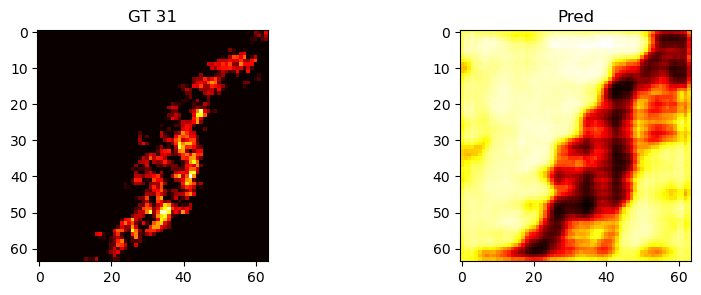

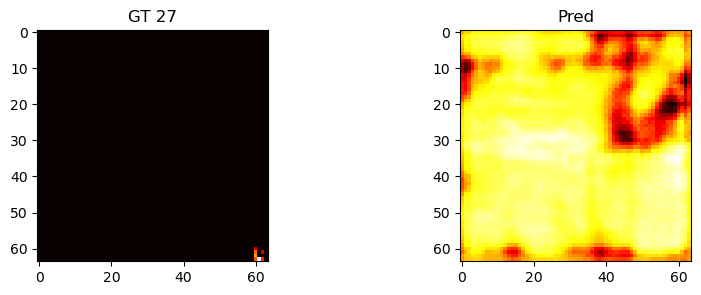

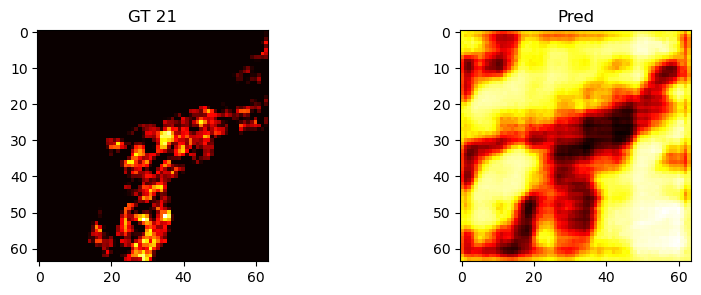

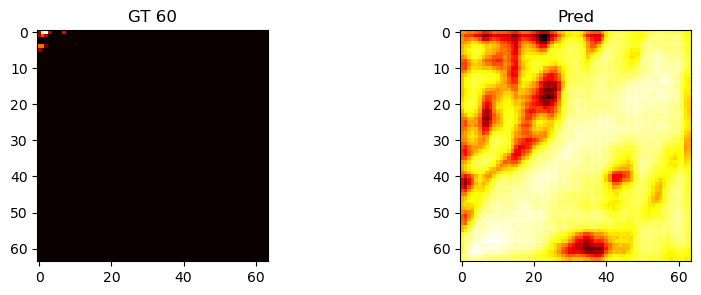

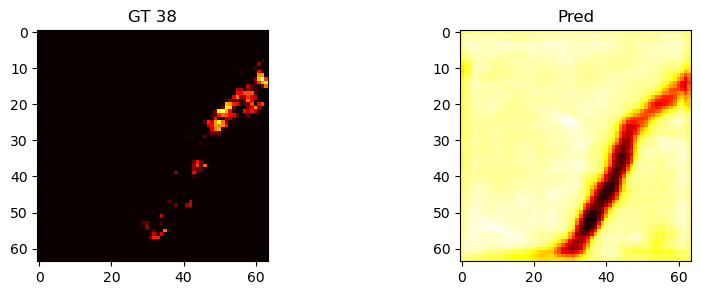

In [372]:
import random

model.eval()

indices = random.sample(range(len(X_test)), 5)

with torch.no_grad():
    preds = torch.sigmoid(model(X_test[indices]))

for j, i in enumerate(indices):
    plt.figure(figsize=(10,3))
    
    plt.subplot(1,2,1)
    plt.imshow(y_test[i][0].cpu(), cmap='hot')
    plt.title(f"GT {i}")
    
    plt.subplot(1,2,2)
    plt.imshow(preds[j][0].cpu(), cmap='hot')
    plt.title("Pred")
    
    plt.show()

In [273]:
import torch
model_cpu = model.to('cpu')
torch.save(model_cpu.state_dict(), 'unet_model.pth')

In [331]:
weights = model.fuse.weight.data.cpu().numpy()  # shape: (1,6,1,1)
weights = weights.reshape(-1)

In [332]:
print("Pred influence:", weights[0])
print("Band influences:", weights[1:])

Pred influence: -0.29122788
Band influences: [-0.04074143  0.13501823  0.30553877 -0.02366769 -0.16845848]


In [364]:
model.eval()

with torch.no_grad():
    logits = model(X_test.to(device))
    probs = torch.sigmoid(logits)

0.5219690799713135 0.6387312412261963


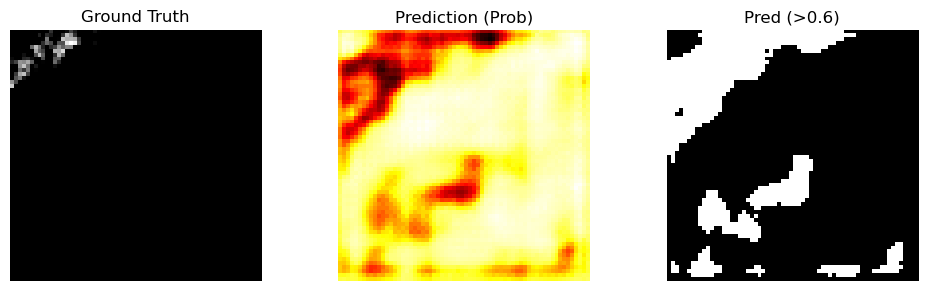

In [413]:
import matplotlib.pyplot as plt
import torch

model.eval()

# choose some samples
indices = [40]  # or random.sample(range(len(X_test)), 3)

threshold = 0.6  # adjust if needed

with torch.no_grad():
    logits = model(X_test[indices].to(device))
    probs = torch.sigmoid(logits)
    print(probs.min().item(), probs.max().item())
    preds = (probs < threshold).float()

for i, idx in enumerate(indices):
    plt.figure(figsize=(10,3))

    # Ground Truth
    plt.subplot(1,3,1)
    plt.imshow(y_test[idx][0].cpu(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    # Probability map
    plt.subplot(1,3,2)
    plt.imshow(probs[i][0].cpu(), cmap='hot')
    plt.title("Prediction (Prob)")
    plt.axis('off')

    # Thresholded prediction
    plt.subplot(1,3,3)
    plt.imshow(preds[i][0].cpu(), cmap='gray')
    plt.title(f"Pred (>{threshold})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [378]:
def compute_iou(preds, targets):
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

In [367]:
def compute_accuracy(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(preds)
    return correct / total

In [414]:
iou = compute_iou(preds, y_test.to(device))
acc = compute_accuracy(preds, y_test.to(device))

print("IoU:", iou.item())
print("Accuracy:", acc.item())

IoU: 0.063003309071064
Accuracy: 45.36962890625


In [369]:
def batch_iou(preds, targets):
    ious = []
    for i in range(preds.shape[0]):
        p = preds[i]
        t = targets[i]

        intersection = (p * t).sum()
        union = p.sum() + t.sum() - intersection

        iou = (intersection + 1e-6) / (union + 1e-6)
        ious.append(iou)

    return torch.mean(torch.stack(ious))